
CORRECTED SIMULATION: Two-Level Quantum System

System Configuration:
  Hamiltonian: H = (ω/2) σ_z, ω = 1.0
  Noise operators: V_1 = σ_x, V_2 = σ_y
  True parameters: θ = [0.25 0.15]
  Noise potential: V = 0.25 σ_x + 0.15 σ_y

Measurement Setup:
  Initial state: ground state
  Observables: X = σ_z, σ_x

ALGORITHM 1: Quantum Parameter Estimation (CORRECTED)
Parameters to estimate: 2
Number of observables: 2
Perturbation ε: 0.15
Initial guess: [0.4 0.4]
True values: [0.25 0.15]
Measurements: [np.float64(-0.34000000000000086), np.float64(0.0)]


ESTIMATION COMPLETE
Final estimate: [-0.23801432 -0.23801432]
True values:    [0.25 0.15]
Absolute error: 0.623469
Relative error: 213.85%
Measurements: [np.float64(-0.34000000000000086), np.float64(0.0)]
Predictions:  [np.float64(-0.33990488837024324), np.float64(0.0)]


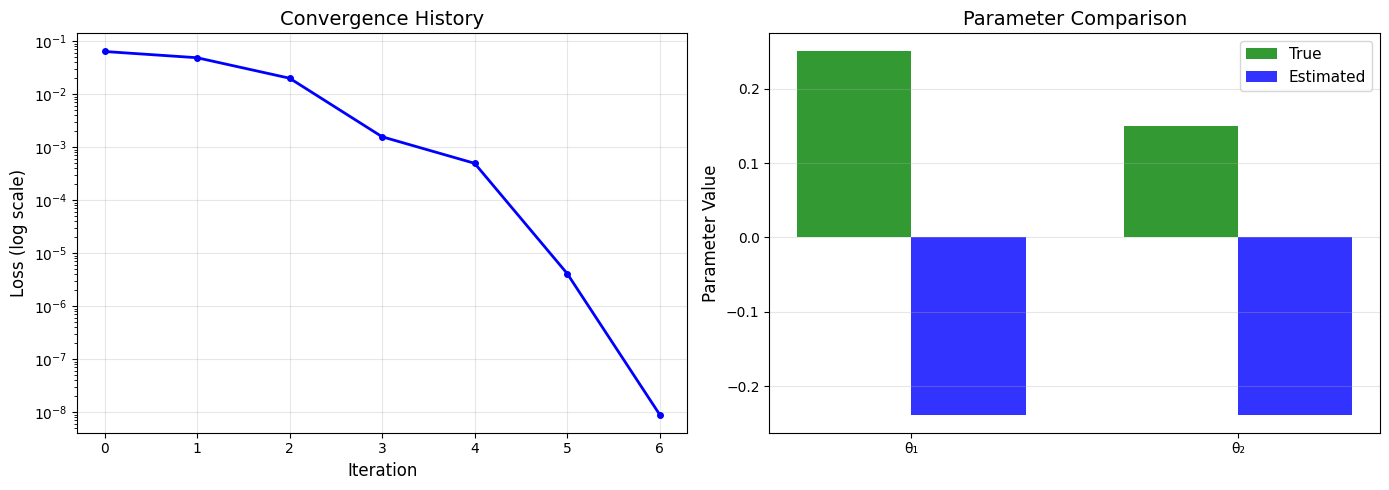

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

class QuantumParameterEstimator:
    
    def __init__(self, hamiltonian: np.ndarray, V_operators: List[np.ndarray], 
                 epsilon: float = 0.1, dt: float = 0.01):
        assert np.allclose(hamiltonian, hamiltonian.conj().T), "Hamiltonian must be Hermitian"
        self.H = hamiltonian
        self.V_ops = V_operators
        self.epsilon = epsilon
        self.dt = dt
        self.dim = hamiltonian.shape[0]
        self.num_params = len(V_operators)
        for i, V in enumerate(V_operators):
            assert np.allclose(V, V.conj().T), f"V_operator {i} must be Hermitian"
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.H)
        self.eigenprojections = self._compute_eigenprojections()
        ground_idx = np.argmin(self.eigenvalues)
        self.rho_0 = np.outer(self.eigenvectors[:, ground_idx], self.eigenvectors[:, ground_idx].conj())
        self.convergence_history = []
        
    def set_initial_state(self, rho_0: np.ndarray):
        assert np.allclose(rho_0, rho_0.conj().T), "Initial state must be Hermitian"
        assert np.abs(np.trace(rho_0) - 1.0) < 1e-10, "Initial state must be normalized"
        self.rho_0 = rho_0.copy()
        
    def _compute_eigenprojections(self) -> List[np.ndarray]:
        projections = []
        for i in range(self.dim):
            v = self.eigenvectors[:, i:i+1]
            P = v @ v.conj().T
            projections.append(P)
        return projections
    
    def _U0_evolution(self, t: float) -> np.ndarray:
        if abs(t) < 1e-12:
            return np.eye(self.dim, dtype=complex)
        U0 = np.zeros((self.dim, self.dim), dtype=complex)
        for alpha in range(self.dim):
            phase = np.exp(-1j * self.eigenvalues[alpha] * t)
            U0 += phase * self.eigenprojections[alpha]
        return U0
    
    def _construct_noise_potential(self, theta: np.ndarray) -> np.ndarray:
        V = np.zeros((self.dim, self.dim), dtype=complex)
        for k in range(self.num_params):
            V += theta[k] * self.V_ops[k]
        return V
    
    def _first_order_term_single_realization(self, t: float, V: np.ndarray) -> np.ndarray:
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        dB = np.random.normal(0, np.sqrt(actual_dt), num_steps)
        U1 = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt  
            U0_t_tau = self._U0_evolution(t - tau)
            U0_tau = self._U0_evolution(tau)
            integrand = U0_t_tau @ V @ U0_tau
            U1 += -1j * integrand * dB[i]
        return U1
    
    def _second_order_deterministic_term(self, t: float, V: np.ndarray) -> np.ndarray:
        V2 = V @ V
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        U2_det = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_t_tau = self._U0_evolution(t - tau)
            U0_tau = self._U0_evolution(tau)
            integrand = U0_t_tau @ V2 @ U0_tau
            U2_det += -0.5 * integrand * actual_dt
        return U2_det
    
    def compute_expected_observable(self, observable: np.ndarray, theta: np.ndarray,
                                    t: float, num_realizations: int = 100) -> float:
        V = self._construct_noise_potential(theta)
        V2 = V @ V
        U0_t = self._U0_evolution(t)
        evolved_obs_0 = U0_t.conj().T @ observable @ U0_t
        expectation_0 = np.real(np.trace(self.rho_0 @ evolved_obs_0))
        term1 = np.zeros((self.dim, self.dim), dtype=complex)
        num_steps = max(int(t / self.dt), 1)
        actual_dt = t / num_steps
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            integrand = U0_t.conj().T @ observable @ U0_t_tau @ V2 @ U0_tau
            term1 += -0.5 * integrand * actual_dt
        term2 = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            integrand = U0_tau.conj().T @ V2 @ U0_t_tau.conj().T @ observable @ U0_t
            term2 += -0.5 * integrand * actual_dt
        term3 = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(num_steps):
            tau = (i + 0.5) * actual_dt
            U0_tau = self._U0_evolution(tau)
            U0_t_tau = self._U0_evolution(t - tau)
            integrand = (U0_tau.conj().T @ V @ U0_t_tau.conj().T @ 
                         observable @ U0_t_tau @ V @ U0_tau)
            term3 += integrand * actual_dt
        evolved_obs_2 = term1 + term2 + term3
        expectation_2 = np.real(np.trace(self.rho_0 @ evolved_obs_2))
        total_expectation = expectation_0 + self.epsilon**2 * expectation_2
        return total_expectation
    
    def compute_Q_matrix(self, observable: np.ndarray) -> np.ndarray:
        X = observable
        Q = np.zeros((self.num_params, self.num_params))
        for k in range(self.num_params):
            for m in range(self.num_params):
                Vk = self.V_ops[k]
                Vm = self.V_ops[m]
                Q_km = 0.0
                for alpha in range(self.dim):
                    P_alpha = self.eigenprojections[alpha]
                    term1 = np.trace(self.rho_0 @ P_alpha @ X @ P_alpha @ Vk @ Vm @ P_alpha)
                    term2 = np.trace(self.rho_0 @ P_alpha @ Vk @ Vm @ P_alpha @ X @ P_alpha)
                    term3 = np.trace(self.rho_0 @ P_alpha @ Vk @ P_alpha @ X @ P_alpha @ Vm @ P_alpha)
                    term4 = 0.0
                    for beta in range(self.dim):
                        P_beta = self.eigenprojections[beta]
                        term4 += np.trace(self.rho_0 @ P_alpha @ Vk @ P_beta @ X @ P_beta @ Vm @ P_alpha)
                    Q_km += np.real(term1 + term2 - term3 - term4)
                Q[k, m] = Q_km
        return Q
    
    def time_averaged_measurement(self, observable: np.ndarray, theta: np.ndarray,
                                  t_min: float = 5.0, t_max: float = 20.0, 
                                  num_times: int = 20) -> float:
        times = np.linspace(t_min, t_max, num_times)
        measurements = []
        for t in times:
            E_evolved = self.compute_expected_observable(observable, theta, t)
            U0_t = self._U0_evolution(t)
            evolved_0 = U0_t.conj().T @ observable @ U0_t
            E_0 = np.real(np.trace(self.rho_0 @ evolved_0))
            scaled_diff = -2.0 / (t * self.epsilon**2) * (E_evolved - E_0)
            measurements.append(scaled_diff)
        return np.mean(measurements)
    
    def estimate_parameters(self, observables: List[np.ndarray], 
                            theta_true: np.ndarray = None,
                            initial_guess: np.ndarray = None,
                            tol: float = 1e-5,
                            verbose: bool = True) -> Tuple[np.ndarray, Dict]:
        if initial_guess is None:
            initial_guess = np.random.uniform(0.1, 0.3, self.num_params)
        Q_list = [self.compute_Q_matrix(obs) for obs in observables]
        if theta_true is not None:
            measurements = [self.time_averaged_measurement(obs, theta_true, 
                                                           t_min=8.0, t_max=15.0, 
                                                           num_times=10) for obs in observables]
        else:
            raise ValueError("theta_true required for simulation")
        if verbose:
            print("="*70)
            print("ALGORITHM 1: Quantum Parameter Estimation (CORRECTED)")
            print("="*70)
            print(f"Parameters to estimate: {self.num_params}")
            print(f"Number of observables: {len(observables)}")
            print(f"Perturbation ε: {self.epsilon}")
            print(f"Initial guess: {initial_guess}")
            print(f"True values: {theta_true}")
            print(f"Measurements: {measurements}")
            print()

        def loss(theta):
            l = 0.0
            for i, Q in enumerate(Q_list):
                pred = theta @ Q @ theta
                l += (pred - measurements[i]) ** 2
            return l

        def callback(theta):
            change = np.linalg.norm(theta - initial_guess)  # Dummy, or compute something
            self.convergence_history.append(loss(theta))
        
        result = minimize(loss, initial_guess, method='BFGS', tol=tol, callback=callback)
        theta = result.x
        info = {
            'success': result.success,
            'message': result.message,
            'nit': result.nit,
            'Q_list': Q_list,
            'measurements': measurements,
            'final_predictions': [theta @ Q @ theta for Q in Q_list],
            'convergence_history': self.convergence_history
        }
        
        if verbose:
            print("\n" + "="*70)
            print("ESTIMATION COMPLETE")
            print("="*70)
            print(f"Final estimate: {theta}")
            print(f"True values:    {theta_true}")
            print(f"Absolute error: {np.linalg.norm(theta - theta_true):.6f}")
            print(f"Relative error: {np.linalg.norm(theta - theta_true) / np.linalg.norm(theta_true) * 100:.2f}%")
            print(f"Measurements: {measurements}")
            print(f"Predictions:  {info['final_predictions']}")
            print("="*70)
        return theta, info

def run_corrected_simulation():
    print("\n" + "="*70)
    print("CORRECTED SIMULATION: Two-Level Quantum System")
    print("="*70 + "\n")
    omega = 1.0
    H = omega / 2 * np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sigma_y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
    V_operators = [sigma_x, sigma_y]
    theta_true = np.array([0.25, 0.15])
    print("System Configuration:")
    print(f"  Hamiltonian: H = (ω/2) σ_z, ω = {omega}")
    print(f"  Noise operators: V_1 = σ_x, V_2 = σ_y")
    print(f"  True parameters: θ = {theta_true}")
    print(f"  Noise potential: V = {theta_true[0]:.2f} σ_x + {theta_true[1]:.2f} σ_y")
    print()
    estimator = QuantumParameterEstimator(
        hamiltonian=H,
        V_operators=V_operators,
        epsilon=0.15, 
        dt=0.02
    )
    sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    observables = [sigma_z, sigma_x]
    print("Measurement Setup:")
    print(f"  Initial state: ground state")
    print(f"  Observables: X = σ_z, σ_x")
    print()
    theta_estimated, info = estimator.estimate_parameters(
        observables=observables,
        theta_true=theta_true,
        initial_guess=np.array([0.4, 0.4]),
        tol=5e-3,
        verbose=True
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].semilogy(info['convergence_history'], 'b-', linewidth=2, marker='o', markersize=4)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss (log scale)', fontsize=12)
    axes[0].set_title('Convergence History', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    params = ['θ₁', 'θ₂']
    x = np.arange(len(params))
    width = 0.35

    axes[1].bar(x - width/2, theta_true, width, label='True', alpha=0.8, color='green')
    axes[1].bar(x + width/2, theta_estimated, width, label='Estimated', alpha=0.8, color='blue')
    axes[1].set_ylabel('Parameter Value', fontsize=12)
    axes[1].set_title('Parameter Comparison', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(params)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('algorithm1_corrected.png', dpi=150, bbox_inches='tight')
    plt.show()
    return theta_estimated, theta_true, info

if __name__ == "__main__":
    np.random.seed(42)  # For reproducibility
    theta_est, theta_true, info = run_corrected_simulation()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import simpson
from typing import List, Tuple, Optional, Dict
import warnings
warnings.filterwarnings('ignore')
try:
    from qiskit.quantum_info import Operator, DensityMatrix
    from qiskit import QuantumCircuit
    QISKIT_AVAILABLE = True
except ImportError:
    print("Warning: Qiskit not available. Using NumPy-only implementation.")
    QISKIT_AVAILABLE = False

class QuantumNoiseEstimator:

    def __init__(self, hamiltonian: np.ndarray, 
                 noise_operators: List[np.ndarray], 
                 epsilon: float = 0.1, 
                 dim: int = 2):
        self.H = hamiltonian
        self.Vk_list = noise_operators
        self.epsilon = epsilon
        self.dim = dim
        self.p = len(noise_operators)  
        self._validate_inputs()
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.H)
        self.eigenprojections = self._compute_eigenprojections()

        print(f"Initialized QuantumNoiseEstimator:")
        print(f" - System dimension: {self.dim}")
        print(f" - Number of noise parameters: {self.p}")
        print(f" - Perturbation strength ε: {self.epsilon}")
        print(f" - Hamiltonian eigenvalues: {self.eigenvalues}")

    def _validate_inputs(self):
        assert self.H.shape == (self.dim, self.dim), "Hamiltonian must be square"
        assert np.allclose(self.H, self.H.conj().T), "Hamiltonian must be Hermitian"
        for i, Vk in enumerate(self.Vk_list):
            assert Vk.shape == (self.dim, self.dim), f"Noise operator {i} must be square"
            assert np.allclose(Vk, Vk.conj().T), f"Noise operator {i} must be Hermitian"

    def _compute_eigenprojections(self) -> List[np.ndarray]:
        projections = []
        for i in range(self.dim):
            v = self.eigenvectors[:, i].reshape(-1, 1)
            P = v @ v.conj().T
            projections.append(P)
        return projections

    def generate_brownian_motion(self,
                                 t_final: float,
                                 n_steps: int,
                                 n_realizations: int = 1) -> Tuple[np.ndarray, np.ndarray]:
        dt = t_final / n_steps
        times = np.linspace(0, t_final, n_steps + 1)
        dB = np.random.normal(0, np.sqrt(dt), (n_realizations, n_steps))
        brownian_paths = np.zeros((n_realizations, n_steps + 1))
        brownian_paths[:, 1:] = np.cumsum(dB, axis=1)
        return times, brownian_paths

    def U0(self, t: float) -> np.ndarray:
        return expm(-1j * t * self.H)

    def compute_V(self, theta: np.ndarray) -> np.ndarray:
        assert len(theta) == self.p, f"Need {self.p} parameters, got {len(theta)}"
        V = np.zeros((self.dim, self.dim), dtype=complex)
        for k in range(self.p):
            V += theta[k] * self.Vk_list[k]
        return V

    def compute_U1(self,
                   t: float,
                   theta: np.ndarray,
                   brownian_times: np.ndarray,
                   brownian_path: np.ndarray) -> np.ndarray:
        V = self.compute_V(theta)
        idx = np.argmin(np.abs(brownian_times - t))
        n_steps = idx
        U1 = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dB = brownian_path[i] - brownian_path[i-1]
            integrand = self.U0(t - tau) @ V @ self.U0(tau)
            U1 += -1j * integrand * dB
        return U1

    def compute_U2(self,
                   t: float,
                   theta: np.ndarray,
                   brownian_times: np.ndarray,
                   brownian_path: np.ndarray,
                   U1: Optional[np.ndarray] = None) -> np.ndarray:
        V = self.compute_V(theta)
        V2 = V @ V
        idx = np.argmin(np.abs(brownian_times - t))
        n_steps = idx
        U2 = np.zeros((self.dim, self.dim), dtype=complex)
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dB = brownian_path[i] - brownian_path[i-1]
            U1_tau = self.compute_U1(tau, theta, brownian_times, brownian_path)
            integrand = self.U0(t - tau) @ V @ U1_tau
            U2 += -1j * integrand * dB
        for i in range(1, n_steps + 1):
            tau = brownian_times[i-1]
            dtau = brownian_times[i] - brownian_times[i-1]
            integrand = self.U0(t - tau) @ V2 @ self.U0(tau)
            U2 += -0.5 * integrand * dtau
        return U2

    def compute_U_perturbative(self,
                               t: float,
                               theta: np.ndarray,
                               brownian_times: np.ndarray,
                               brownian_path: np.ndarray,
                               order: int = 2) -> np.ndarray:
        U = self.U0(t)
        if order >= 1:
            U1 = self.compute_U1(t, theta, brownian_times, brownian_path)
            U += self.epsilon * U1
        if order >= 2:
            U2 = self.compute_U2(t, theta, brownian_times, brownian_path)
            U += self.epsilon**2 * U2
        return U

    def compute_observable_evolution(self,
                                     X: np.ndarray,
                                     t: float,
                                     theta: np.ndarray,
                                     brownian_times: np.ndarray,
                                     brownian_path: np.ndarray) -> np.ndarray:
        U = self.compute_U_perturbative(t, theta, brownian_times, brownian_path)
        return U.conj().T @ X @ U

    def compute_expectation_value(self,
                                  X: np.ndarray,
                                  rho0: np.ndarray,
                                  t: float,
                                  theta: np.ndarray,
                                  n_steps: int = 1000) -> float:
        V = self.compute_V(theta)
        V2 = V @ V
        U0 = self.U0(t)
        U0_dag = U0.conj().T
        X0 = U0_dag @ X @ U0
        exp0 = np.trace(rho0 @ X0).real
        dt = t / n_steps
        term1 = 0.0
        term2 = 0.0
        term3 = 0.0
        for i in range(n_steps):
            tau = (i + 0.5) * dt 
            U0_tau = self.U0(tau)
            U0_dag_tau = U0_tau.conj().T
            U0_t_tau = self.U0(t - tau)
            U0_dag_t_tau = U0_t_tau.conj().T
            int1 = U0_dag @ X @ U0_t_tau @ V2 @ U0_tau
            term1 += -0.5 * np.trace(rho0 @ int1).real * dt
            int2 = U0_dag_tau @ V2 @ U0_dag_t_tau @ X @ U0
            term2 += -0.5 * np.trace(rho0 @ int2).real * dt
            int3 = U0_dag_tau @ V @ U0_dag_t_tau @ X @ U0_t_tau @ V @ U0_tau
            term3 += np.trace(rho0 @ int3).real * dt
        exp2 = term1 + term2 + term3
        return exp0 + self.epsilon**2 * exp2

    def compute_Q_function(self,
                           X: np.ndarray,
                           rho0: np.ndarray,
                           theta: np.ndarray) -> float:
        Q_matrix = np.zeros((self.p, self.p))
        for k in range(self.p):
            for m in range(self.p):
                Vk = self.Vk_list[k]
                Vm = self.Vk_list[m]
                Q_km = 0
                for alpha in range(self.dim):
                    Pa = self.eigenprojections[alpha]
                    term1 = Pa @ X @ Pa @ Vk @ Vm @ Pa
                    term2 = Pa @ Vk @ Vm @ Pa @ X @ Pa
                    term3 = -Pa @ Vk @ Pa @ X @ Pa @ Vm @ Pa
                    term4 = np.zeros((self.dim, self.dim), dtype=complex)
                    for beta in range(self.dim):
                        Pb = self.eigenprojections[beta]
                        term4 += -Pa @ Vk @ Pb @ X @ Pb @ Vm @ Pa
                    Q_km += np.trace(rho0 @ (term1 + term2 + term3 + term4)).real
                Q_matrix[k, m] = Q_km
        Q_value = theta @ Q_matrix @ theta
        return Q_value

    def estimate_parameters(self,
                            X_observables: List[np.ndarray],
                            rho0: np.ndarray,
                            true_theta: np.ndarray,
                            t_final: float = 10.0,
                            n_measurements: int = 50,
                            n_steps: int = 1000) -> np.ndarray:
        print("\n" + "="*70)
        print("QUANTUM PARAMETER ESTIMATION ALGORITHM")
        print("="*70)
        times = np.linspace(t_final / 2, t_final, n_measurements)
        Q_measurements = []
        for idx, X in enumerate(X_observables):
            print(f"\nProcessing Observable {idx+1}/{len(X_observables)}...")
            scaled_values = []
            for t in times:
                exp_val = self.compute_expectation_value(
                    X, rho0, t, true_theta, n_steps
                )
                U0 = self.U0(t)
                U0_dag = U0.conj().T
                X0 = U0_dag @ X @ U0
                exp_val0 = np.trace(rho0 @ X0).real
                scaled = -2 / (self.epsilon**2 * t) * (exp_val - exp_val0)
                scaled_values.append(scaled)
            Q_measurement = np.mean(scaled_values)
            Q_measurements.append(Q_measurement)
            print(f" Time-averaged scaled deviation: {Q_measurement:.6f}")
        print("\n" + "-"*70)
        print("Parameter Estimation via Quadratic Fitting")
        print("-"*70)
        theta_estimated = self._estimate_via_least_squares(
            X_observables, rho0, Q_measurements
        )
        print(f"\nTrue parameters: {true_theta}")
        print(f"Estimated parameters: {theta_estimated}")
        print(f"Estimation error: {np.linalg.norm(theta_estimated - true_theta):.6f}")
        return theta_estimated

    def _estimate_via_least_squares(self,
                                    X_observables: List[np.ndarray],
                                    rho0: np.ndarray,
                                    Q_measurements: List[float]) -> np.ndarray:
        from scipy.optimize import minimize
        def objective(theta):
            error = 0
            for X, Q_meas in zip(X_observables, Q_measurements):
                Q_pred = self.compute_Q_function(X, rho0, theta)
                error += (Q_pred - Q_meas)**2
            return error
        initial_guess = np.zeros(self.p)
        result = minimize(objective, initial_guess, method='BFGS')
        return result.x

class QuantumNoiseSimulator:

    @staticmethod
    def create_pauli_system(epsilon: float = 0.1) -> QuantumNoiseEstimator:
        sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
        sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
        sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
        omega = 1.0
        H = omega * sigma_z
        noise_operators = [sigma_x, sigma_y, sigma_z]
        return QuantumNoiseEstimator(H, noise_operators, epsilon, dim=2)

    @staticmethod
    def create_harmonic_oscillator(n_levels: int = 4,
                                   epsilon: float = 0.1) -> QuantumNoiseEstimator:
        a = np.diag(np.sqrt(np.arange(1, n_levels)), 1)
        a_dag = a.T
        n_op = a_dag @ a
        omega = 1.0
        H = omega * (n_op + 0.5 * np.eye(n_levels))
        x_op = (a + a_dag) / np.sqrt(2)
        p_op = -1j * (a - a_dag) / np.sqrt(2)
        noise_operators = [x_op, p_op, n_op]
        return QuantumNoiseEstimator(H, noise_operators, epsilon, dim=n_levels)

def example_qubit_system():
    print("\n" + "="*70)
    print("EXAMPLE 1: QUBIT SYSTEM WITH PAULI NOISE")
    print("="*70)
    epsilon = 0.05
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon)
    true_theta = np.array([0.3, 0.5, 0.2])
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    X_observables = [sigma_x, sigma_y, sigma_z]
    theta_est = estimator.estimate_parameters(
        X_observables,
        rho0,
        true_theta,
        t_final=5.0,
        n_measurements=20,
        n_steps=500
    )
    return estimator, true_theta, theta_est

def example_time_evolution():
    print("\n" + "="*70)
    print("EXAMPLE 2: TIME EVOLUTION VISUALIZATION")
    print("="*70)
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.1)
    theta = np.array([0.5, 0.3, 0.2])
    t_final = 10.0
    n_steps = 1000
    times, brownian_paths = estimator.generate_brownian_motion(
        t_final, n_steps, n_realizations=1
    )
    brownian_path = brownian_paths[0]
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    print("\nComputing time evolution...")
    expectation_values = []
    time_points = times[::50]
    for t in time_points:
        U = estimator.compute_U_perturbative(t, theta, times, brownian_path, order=2)
        X_evolved = U.conj().T @ sigma_z @ U
        exp_val = np.trace(rho0 @ X_evolved).real
        expectation_values.append(exp_val)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(times, brownian_path, 'b-', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('B(t)')
    plt.title('Brownian Motion Trajectory')
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(time_points, expectation_values, 'r-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('⟨σz⟩(t)')
    plt.title('Observable Evolution Under Noise')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('time_evolution.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'time_evolution.png'")
    plt.show()
    return times, expectation_values

def example_parameter_scan():
    print("\n" + "="*70)
    print("EXAMPLE 3: PARAMETER SPACE SCAN")
    print("="*70)
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.1)
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    theta3_fixed = 0.2
    theta1_range = np.linspace(0, 1, 30)
    theta2_range = np.linspace(0, 1, 30)
    Q_values = np.zeros((len(theta1_range), len(theta2_range)))
    print("\nScanning parameter space...")
    for i, theta1 in enumerate(theta1_range):
        for j, theta2 in enumerate(theta2_range):
            theta = np.array([theta1, theta2, theta3_fixed])
            Q_values[i, j] = estimator.compute_Q_function(sigma_x, rho0, theta)
    plt.figure(figsize=(10, 8))
    T1, T2 = np.meshgrid(theta1_range, theta2_range)
    plt.contourf(T1, T2, Q_values.T, levels=20, cmap='viridis')
    plt.colorbar(label='Q(θ₁, θ₂)')
    plt.xlabel('θ₁')
    plt.ylabel('θ₂')
    plt.title(f'Quadratic Function Q(θ) Landscape (θ₃ = {theta3_fixed})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('parameter_scan.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'parameter_scan.png'")
    plt.show()
    return Q_values

def example_convergence_analysis():
    print("\n" + "="*70)
    print("EXAMPLE 4: CONVERGENCE ANALYSIS")
    print("="*70)
    estimator = QuantumNoiseSimulator.create_pauli_system(epsilon=0.05)
    true_theta = np.array([0.4, 0.6, 0.3])
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
    X_observables = [sigma_x, sigma_y, sigma_z]
    n_measurement_values = [5, 10, 20, 50, 100]
    errors = []
    print("\nTesting convergence with increasing measurements...")
    for n_meas in n_measurement_values:
        print(f"\n Testing with {n_meas} measurements...")
        theta_est = estimator.estimate_parameters(
            X_observables,
            rho0,
            true_theta,
            t_final=5.0,
            n_measurements=n_meas,
            n_steps=300
        )
        error = np.linalg.norm(theta_est - true_theta)
        errors.append(error)
    plt.figure(figsize=(10, 6))
    plt.loglog(n_measurement_values, errors, 'bo-', markersize=10, linewidth=2)
    plt.xlabel('Number of Measurements')
    plt.ylabel('Estimation Error ||θ_est - θ_true||')
    plt.title('Convergence of Parameter Estimation')
    plt.grid(True, alpha=0.3, which='both')
    theoretical = errors[0] * (np.array(n_measurement_values) / n_measurement_values[0])**(-0.5)
    plt.loglog(n_measurement_values, theoretical, 'r--',
               linewidth=2, label='1/√N scaling')
    plt.legend()
    plt.tight_layout()
    plt.savefig('convergence_analysis.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'convergence_analysis.png'")
    plt.show()
    return n_measurement_values, errors

def main():
    print("\n" + "="*70)
    print(" QUANTUM NOISE ANALYSIS AND CONTROL")
    print(" Implementation of Stochastic Differential Equation Approach")
    print("="*70)
    np.random.seed(42)
    print("\n[Running Example 1: Qubit System]")
    estimator1, true_theta1, est_theta1 = example_qubit_system()
    print("\n[Running Example 2: Time Evolution]")
    times, expectations = example_time_evolution()
    print("\n[Running Example 3: Parameter Scan]")
    Q_landscape = example_parameter_scan()
    print("\n[Running Example 4: Convergence Analysis]")
    n_vals, errors = example_convergence_analysis()
    print("\n" + "="*70)
    print("ALL EXAMPLES COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\nGenerated files:")
    print(" - time_evolution.png")
    print(" - parameter_scan.png")
    print(" - convergence_analysis.png")
    print("\nFor more information, see the paper:")
    print("'Stochastic Differential Equations Approaches to")
    print(" Quantum System Noise Analysis and Control'")
    print("="*70 + "\n")

if __name__ == "__main__":
    main()


 QUANTUM NOISE ANALYSIS AND CONTROL
 Implementation of Stochastic Differential Equation Approach

[Running Example 1: Qubit System]

EXAMPLE 1: QUBIT SYSTEM WITH PAULI NOISE
Initialized QuantumNoiseEstimator:
 - System dimension: 2
 - Number of noise parameters: 3
 - Perturbation strength ε: 0.05
 - Hamiltonian eigenvalues: [-1.  1.]

QUANTUM PARAMETER ESTIMATION ALGORITHM

Processing Observable 1/3...
 Time-averaged scaled deviation: 0.041608

Processing Observable 2/3...
 Time-averaged scaled deviation: -0.032719

Processing Observable 3/3...
 Time-averaged scaled deviation: 1.360000

----------------------------------------------------------------------
Parameter Estimation via Quadratic Fitting
----------------------------------------------------------------------

True parameters: [0.3 0.5 0.2]
Estimated parameters: [0. 0. 0.]
Estimation error: 0.616441

[Running Example 2: Time Evolution]

EXAMPLE 2: TIME EVOLUTION VISUALIZATION
Initialized QuantumNoiseEstimator:
 - System dimen